# PRODIGY-SST — Analítica descriptiva (capa Gold)

**Proyecto:** sistema de monitoreo con ciencia de datos para **MYPEs de construcción** en **San Román (Puno)**. **Arquitectura medallón:** bronze → silver → **gold** (este notebook usa tablas Gold exportadas a Excel).

**Idea central:** detectar, analizar y prevenir riesgos laborales con **IF** e **IS**; el producto final incluye **tablero interactivo** (Metabase / Streamlit) y alertas frente a **umbrales legales** (DS 005-2021-TR: IF ≤ 45, IS ≤ 100; Ley N° 29783).

**Problema contextual:** IF > 60 e IS > 150 frecuentemente observados en el territorio vs. metas legales; baja capacitación formal. Este cuaderno **cuantifica** IF/IS y causas para priorizar acciones.

| Qué cubre `analisis.ipynb` | Qué queda fuera (otras fases / roles) |
|----------------------------|----------------------------------------|
| KPI mensual por MYPE, causas, tendencias, heatmap, cruces, reporte texto | No sustituye al ingeniero de SST; HHT puede estar estimado en origen |
| Comparación con **umbrales legales** y **metas del proyecto** (celda siguiente) | Alertas e-mail/WhatsApp y Metabase se implementan en el tablero operativo |

---

## Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
df_kpi = pd.read_excel('gold_kpi_mensual_mype.xlsx')
df_causas = pd.read_excel('gold_top_causas_mensual.xlsx')

# Convertir codmes a datetime para análisis temporal
df_kpi['fecha'] = pd.to_datetime(df_kpi['codmes'].astype(str) + '01', format='%Y%m%d')
df_causas['fecha'] = pd.to_datetime(df_causas['codmes'].astype(str) + '01', format='%Y%m%d')

print(f" df_kpi: {df_kpi.shape} | Periodo: {df_kpi['codmes'].min()} - {df_kpi['codmes'].max()}")
print(f" df_causas: {df_causas.shape} | MYPEs únicas: {df_causas['mype_id'].nunique()}")

 df_kpi: (96, 9) | Periodo: 202501 - 202512
 df_causas: (612, 7) | MYPEs únicas: 8


## Umbrales legales y metas del proyecto (referencia)

| Referencia | IF | IS |
|------------|----|----|
| **DS 005-2021-TR** (máximos tolerables) | ≤ **45** | ≤ **100** |
| **Metas intermedias PRODIGY-SST** (6 meses) | ≤ **50** | ≤ **120** |
| Situación problemática típica (diagnóstico territorial) | **> 60** | **> 150** |

**Definición en capa Gold (SQL):** los valores exportados a Excel provienen de `gold.kpi_mensual_mype`, calculados a partir de `silver.hht_mensual_last` y `silver.accidentes_enriched`:

- **IF (ifrecuencia)** = `count(accidentes) × 1_000_000 / HHT` (accidentes por millón de horas-hombre).
- **IS (isevidad)** = `sum(días_perdidos) × 1_000_000 / HHT` (días perdidos por millón de horas-hombre).

Esa base es la habitual para comparar con los **límites del DS 005-2021-TR** (IF ≤ 45, IS ≤ 100) cuando la norma expresa los indicadores en la misma referencia por millón de HHT. Ver archivo `sql/gold_layer.sql` en el repositorio.

In [ ]:
# Gold: IF = n_accidentes*1e6/hht, IS = dias_perdidos*1e6/hht (ver sql/gold_layer.sql)
# Referencias normativas y metas PRODIGY-SST (ajustar si la normativa actualiza los límites)
IF_LEGAL_MAX = 45   # DS 005-2021-TR
IS_LEGAL_MAX = 100
IF_META_6M = 50   # meta proyecto intermedia
IS_META_6M = 120

if "ifrecuencia" in df_kpi.columns and "isevidad" in df_kpi.columns:
    viola_if_legal = (df_kpi["ifrecuencia"] > IF_LEGAL_MAX).sum()
    viola_is_legal = (df_kpi["isevidad"] > IS_LEGAL_MAX).sum()
    viola_if_meta = (df_kpi["ifrecuencia"] > IF_META_6M).sum()
    viola_is_meta = (df_kpi["isevidad"] > IS_META_6M).sum()
    n = len(df_kpi)
    print(f"Registros MYPE-mes: {n}")
    print(f"Registros con IF > {IF_LEGAL_MAX} (límite legal): {viola_if_legal} ({100*viola_if_legal/n:.1f}%)")
    print(f"Registros con IS > {IS_LEGAL_MAX} (límite legal): {viola_is_legal} ({100*viola_is_legal/n:.1f}%)")
    print(f"Registros con IF > {IF_META_6M} (meta 6m): {viola_if_meta} | IS > {IS_META_6M} (meta 6m): {viola_is_meta}")
    print("\nMuestra (filas con mayor riesgo vs. norma legal):")
    alertas_norma = df_kpi[
        (df_kpi["ifrecuencia"] > IF_LEGAL_MAX) | (df_kpi["isevidad"] > IS_LEGAL_MAX)
    ][["mype_id", "codmes", "ifrecuencia", "isevidad", "n_accidentes"]].sort_values(
        ["isevidad", "ifrecuencia"], ascending=False
    )
    display(alertas_norma.head(15))
else:
    print("Faltan columnas ifrecuencia / isevidad en df_kpi")

# Insights de KPI (df_kpi)

In [2]:
# Resumen Estadistico por MYPE
# Resumen consolidado
resumen_mype = df_kpi.groupby('mype_id').agg({
    'hht': 'sum',
    'n_accidentes': 'sum',
    'dias_perdidos': 'sum',
    'ifrecuencia': 'mean',
    'isevidad': 'mean'
}).round(2).sort_values('isevidad', ascending=False)

print("📋 Ranking de MYPEs por Severidad (IS):")
print(resumen_mype[['ifrecuencia', 'isevidad', 'n_accidentes', 'dias_perdidos']])

📋 Ranking de MYPEs por Severidad (IS):
             ifrecuencia  isevidad  n_accidentes  dias_perdidos
mype_id                                                        
MYPE-SR-003       920.47   3674.21           120            479
MYPE-SR-002       912.89   3615.05           200            792
MYPE-SR-006       927.79   3548.30           188            719
MYPE-SR-007       911.76   3462.21           148            562
MYPE-SR-008       984.74   3446.58           136            476
MYPE-SR-004       945.82   3377.92           140            500
MYPE-SR-001       922.34   3371.66           180            658
MYPE-SR-005       908.80   2850.81           168            527


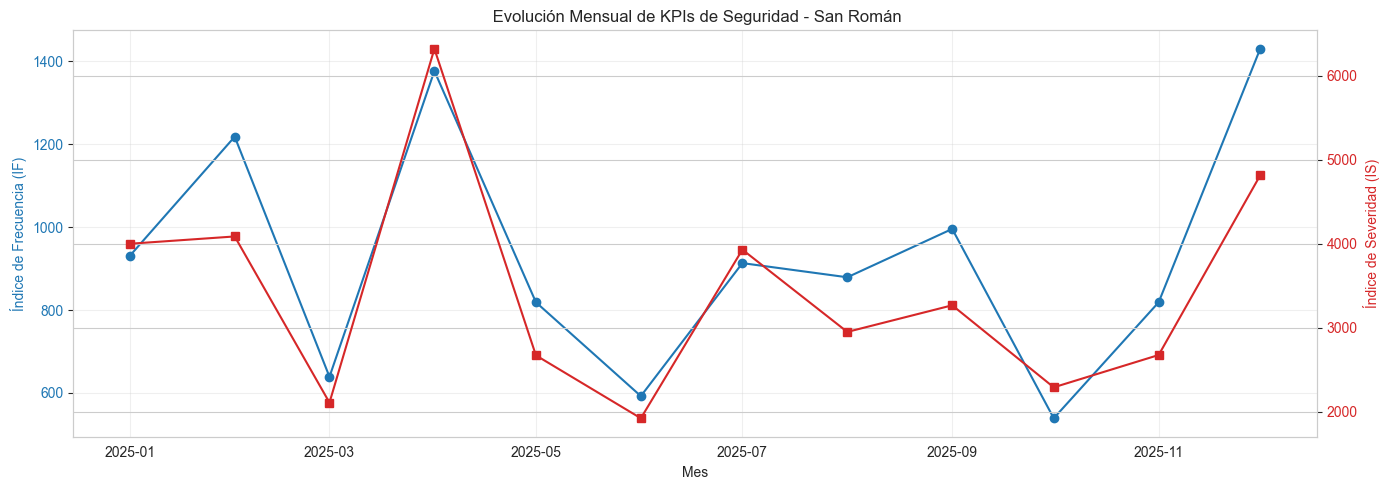


 Impacto de temporada de lluvias:
                   ifrecuencia  isevidad
temporada_lluvias                       
False                   866.72   3251.97
True                   1054.54   3751.08


In [3]:
# Tendencia Temporal de IF e IS
# Evolución mensual consolidada
tendencia = df_kpi.groupby('fecha').agg({
    'ifrecuencia': 'mean',
    'isevidad': 'mean',
    'n_accidentes': 'sum'
}).reset_index()

# Gráfico de tendencia
fig, ax1 = plt.subplots(figsize=(14, 5))

color = 'tab:blue'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Índice de Frecuencia (IF)', color=color)
ax1.plot(tendencia['fecha'], tendencia['ifrecuencia'], color=color, marker='o', label='IF')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Índice de Severidad (IS)', color=color)
ax2.plot(tendencia['fecha'], tendencia['isevidad'], color=color, marker='s', label='IS')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(' Evolución Mensual de KPIs de Seguridad - San Román')
fig.tight_layout()
plt.show()

# Detectar picos estacionales (lluvias: Dic-Mar)
tendencia['mes'] = tendencia['fecha'].dt.month
tendencia['temporada_lluvias'] = tendencia['mes'].isin([12, 1, 2, 3])

comparacion_temporada = tendencia.groupby('temporada_lluvias')[['ifrecuencia', 'isevidad']].mean()
print("\n Impacto de temporada de lluvias:")
print(comparacion_temporada.round(2))

C:\Users\User\AppData\Local\Temp\ipykernel_21052\3367249283.py:15: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


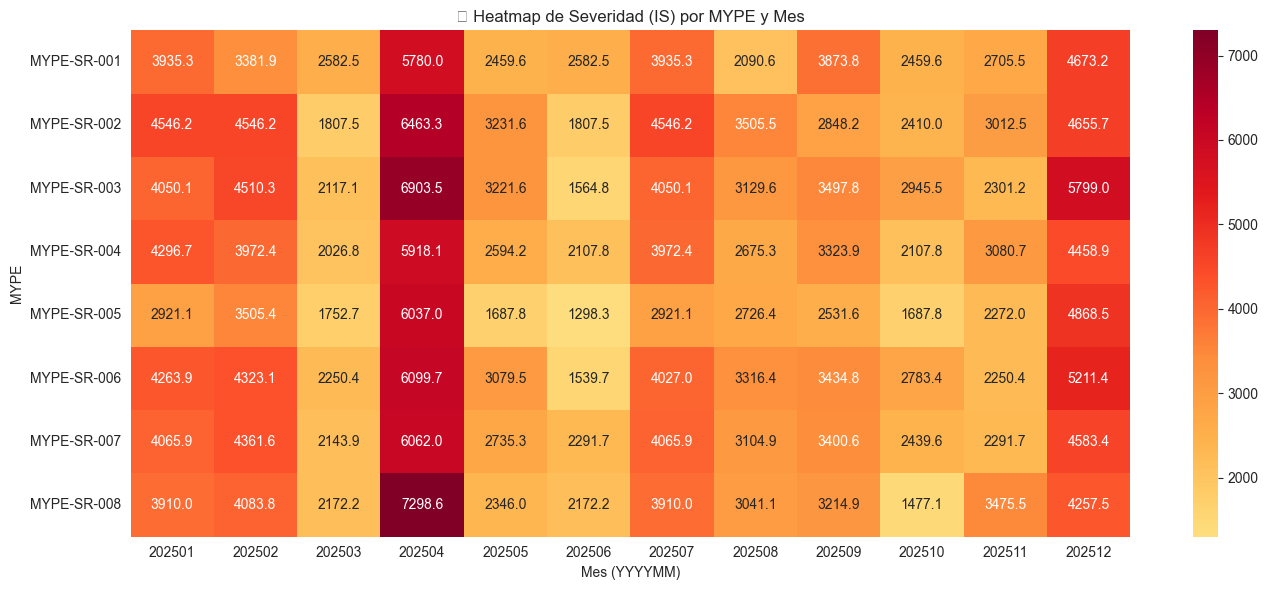


🚨 Alertas Críticas (IS > 5040.0):
        mype_id  codmes     isevidad  n_accidentes
45  MYPE-SR-008  202504  7298.635850            17
30  MYPE-SR-003  202504  6903.534610            15
27  MYPE-SR-002  202504  6463.274361            25
39  MYPE-SR-006  202504  6099.727585            23
42  MYPE-SR-007  202504  6061.950174            18
36  MYPE-SR-005  202504  6037.000974            21
33  MYPE-SR-004  202504  5918.119173            17
80  MYPE-SR-003  202512  5798.969072            15
24  MYPE-SR-001  202504  5779.991392            22
89  MYPE-SR-006  202512  5211.417743            24


In [4]:
# Heatmap de Riesgos: Mype * mes
# Matriz para heatmap
heatmap_data = df_kpi.pivot_table(
    values='isevidad',
    index='mype_id',
    columns='codmes',
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', center=heatmap_data.values.mean())
plt.title('🔥 Heatmap de Severidad (IS) por MYPE y Mes')
plt.xlabel('Mes (YYYYMM)')
plt.ylabel('MYPE')
plt.tight_layout()
plt.show()

# Identificar celdas críticas (IS > percentil 90)
umbral_critico = df_kpi['isevidad'].quantile(0.9)
alertas = df_kpi[df_kpi['isevidad'] > umbral_critico][['mype_id', 'codmes', 'isevidad', 'n_accidentes']]
print(f"\n🚨 Alertas Críticas (IS > {umbral_critico:.1f}):")
print(alertas.sort_values('isevidad', ascending=False).head(10))

# Insights de Causalidad (df_causas)

📊 Distribución de Accidentes por Categoría de Causa:
                    Total_Accidentes  Promedio_por_Registro  \
causa_categoria                                               
Acto inseguro                    503                   2.02   
Condición insegura               407                   2.30   
Gestión SST                      188                   2.16   
Factor personal                  182                   1.84   

                    Frecuencia_Registros  
causa_categoria                           
Acto inseguro                        249  
Condición insegura                   177  
Gestión SST                           87  
Factor personal                       99  


C:\Users\User\AppData\Local\Temp\ipykernel_21052\3974110627.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=causas_categoria.index, y=causas_categoria['Total_Accidentes'], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_21052\3974110627.py:19: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


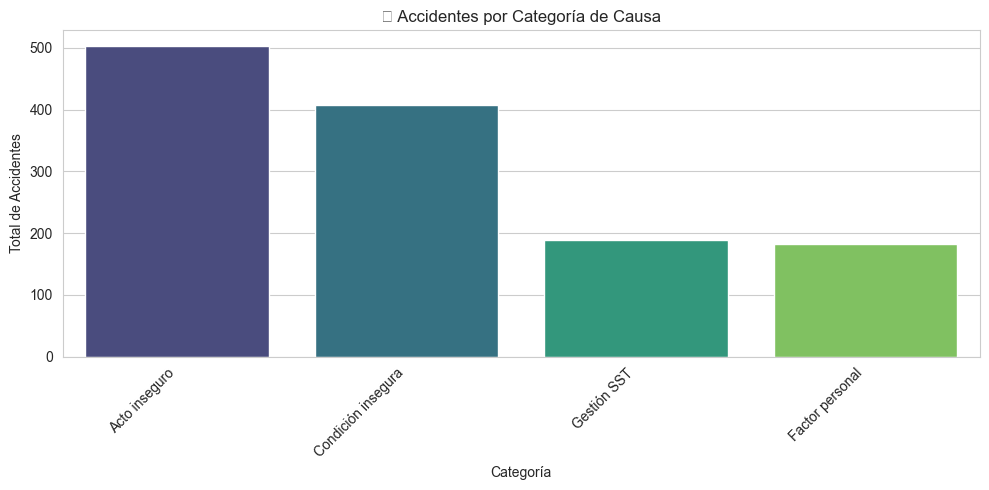

In [5]:
#Distribución de Causas por Categoría
# Agrupación por categoría
causas_categoria = df_causas.groupby('causa_categoria').agg({
    'n_accidentes': ['sum', 'mean', 'count']
}).round(2)
causas_categoria.columns = ['Total_Accidentes', 'Promedio_por_Registro', 'Frecuencia_Registros']
causas_categoria = causas_categoria.sort_values('Total_Accidentes', ascending=False)

print("📊 Distribución de Accidentes por Categoría de Causa:")
print(causas_categoria)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=causas_categoria.index, y=causas_categoria['Total_Accidentes'], palette='viridis')
plt.title('🔍 Accidentes por Categoría de Causa')
plt.xlabel('Categoría')
plt.ylabel('Total de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

🎯 Top 10 Causas Específicas por Frecuencia:
7. [Condición insegura] Caída de objeto → 206 accidentes
10. [Condición insegura] Herramienta defectuosa → 191 accidentes
3. [Acto inseguro] No usar EPP correctamente → 185 accidentes
18. [Gestión SST] Falta de supervisión → 177 accidentes
14. [Factor personal] No apto físicamente (mareos) → 162 accidentes
2. [Acto inseguro] Distracción / apuro → 159 accidentes
6. [Acto inseguro] Uso de celular durante la tarea → 146 accidentes
1. [Acto inseguro] Caminar distraído → 9 accidentes
13. [Factor personal] Fatiga o somnolencia → 9 accidentes
12. [Factor personal] Distracción / fatiga → 7 accidentes


C:\Users\User\AppData\Local\Temp\ipykernel_21052\2934826642.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_causas['causa_especifica'], x=top_causas['n_accidentes'], palette='coolwarm')


C:\Users\User\AppData\Local\Temp\ipykernel_21052\2934826642.py:17: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


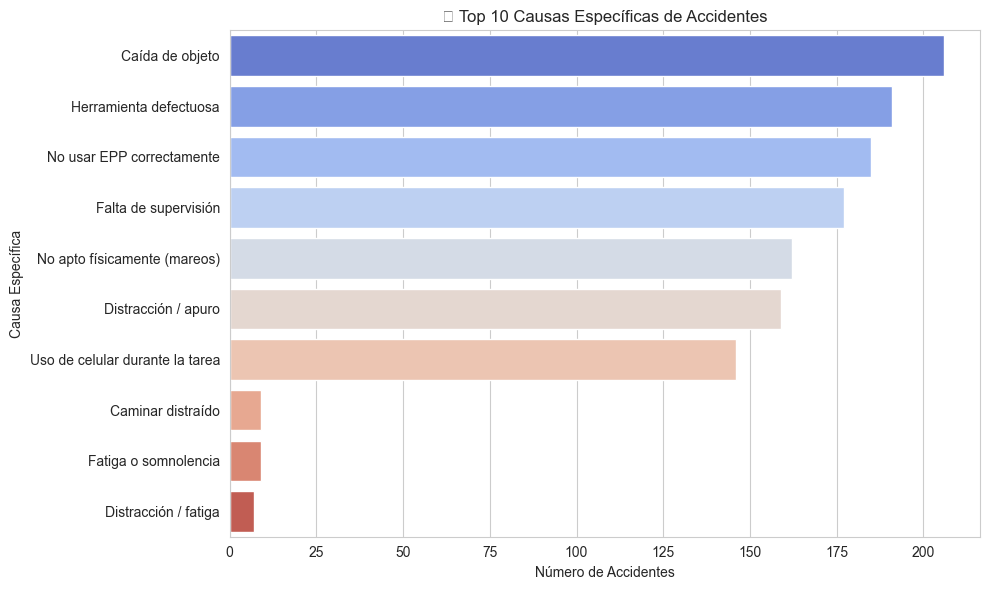

In [6]:
#  Top 10 Causas Específicas de Alto Impacto
# Combinar frecuencia y severidad aproximada
top_causas = df_causas.groupby(['causa_categoria', 'causa_especifica']).agg({
    'n_accidentes': 'sum'
}).reset_index().sort_values('n_accidentes', ascending=False).head(10)

print("🎯 Top 10 Causas Específicas por Frecuencia:")
for idx, row in top_causas.iterrows():
    print(f"{idx+1}. [{row['causa_categoria']}] {row['causa_especifica']} → {row['n_accidentes']} accidentes")

# Gráfico horizontal
plt.figure(figsize=(10, 6))
sns.barplot(y=top_causas['causa_especifica'], x=top_causas['n_accidentes'], palette='coolwarm')
plt.title('🎯 Top 10 Causas Específicas de Accidentes')
plt.xlabel('Número de Accidentes')
plt.ylabel('Causa Específica')
plt.tight_layout()
plt.show()


🏭 Causa Dominante por MYPE:
MYPE-SR-001: Acto inseguro (41.7% de sus accidentes)
MYPE-SR-002: Acto inseguro (38.5% de sus accidentes)
MYPE-SR-003: Condición insegura (40.0% de sus accidentes)
MYPE-SR-004: Acto inseguro (37.1% de sus accidentes)
MYPE-SR-005: Condición insegura (35.7% de sus accidentes)
MYPE-SR-006: Acto inseguro (41.5% de sus accidentes)
MYPE-SR-007: Acto inseguro (48.6% de sus accidentes)
MYPE-SR-008: Acto inseguro (34.6% de sus accidentes)


C:\Users\User\AppData\Local\Temp\ipykernel_21052\3561494617.py:23: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


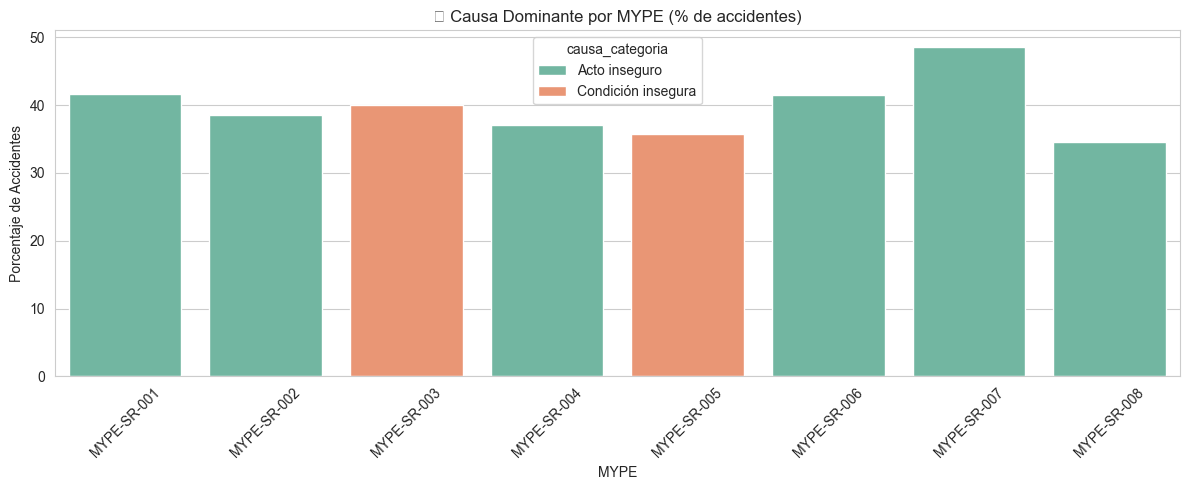

In [7]:
# 🔹 Perfil de Causas por MYPE (Matriz de Riesgo Personalizado)

# Porcentaje de cada causa por MYPE
perfil_causas = df_causas.groupby(['mype_id', 'causa_categoria'])['n_accidentes'].sum().reset_index()
perfil_causas['porcentaje'] = perfil_causas.groupby('mype_id')['n_accidentes'].transform(
    lambda x: x / x.sum() * 100
).round(1)

# Identificar causa dominante por MYPE
causa_dominante = perfil_causas.loc[perfil_causas.groupby('mype_id')['porcentaje'].idxmax()]

print("\n🏭 Causa Dominante por MYPE:")
for _, row in causa_dominante.iterrows():
    print(f"{row['mype_id']}: {row['causa_categoria']} ({row['porcentaje']}% de sus accidentes)")

# Visualización
plt.figure(figsize=(12, 5))
sns.barplot(data=causa_dominante, x='mype_id', y='porcentaje', hue='causa_categoria', palette='Set2')
plt.title('🎯 Causa Dominante por MYPE (% de accidentes)')
plt.xlabel('MYPE')
plt.ylabel('Porcentaje de Accidentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
# Análisis Cruzado: KPIs × Causas
# Merge para análisis conjunto
df_completo = df_kpi.merge(
    df_causas.groupby(['mype_id', 'codmes']).agg({
        'n_accidentes': 'sum',
        'causa_categoria': lambda x: x.value_counts().idxmax()  # causa más frecuente
    }).reset_index().rename(columns={'n_accidentes': 'accidentes_causas', 'causa_categoria': 'causa_principal'}),
    on=['mype_id', 'codmes'],
    how='left'
)

# ¿La causa principal afecta la severidad?
if 'causa_principal' in df_completo.columns:
    severidad_por_causa = df_completo.groupby('causa_principal')['isevidad'].mean().sort_values(ascending=False)
    print("\n⚠️ Severidad Promedio por Tipo de Causa Principal:")
    print(severidad_por_causa.round(2))

    # Gráfico
    plt.figure(figsize=(10, 4))
    sns.barplot(x=severidad_por_causa.index, y=severidad_por_causa.values, palette='Reds_r')
    plt.title('📉 Severidad (IS) Asociada a Causa Principal')
    plt.xlabel('Categoría de Causa')
    plt.ylabel('Índice de Severidad Promedio')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

NameError: name 'df_kpi' is not defined

In [9]:
# Reporte Ejecutivo Automatizado (PRODIGY-SST)
IF_LEGAL, IS_LEGAL = 45, 100  # DS 005-2021-TR (IF/IS Gold = por millón HHT)
IF_META, IS_META = 50, 120   # metas intermedias proyecto (6 meses)


def generar_reporte_ejecutivo(df_kpi, df_causas):
    """Resumen ejecutivo alineado a Ley 29783, DS 005-2021-TR y tablero PRODIGY-SST."""

    # Métricas globales
    total_accidentes = df_kpi['n_accidentes'].sum()
    total_dias = df_kpi['dias_perdidos'].sum()
    if_global = df_kpi['ifrecuencia'].mean()
    is_global = df_kpi['isevidad'].mean()
    n = len(df_kpi)
    pct_if_legal = 100 * ((df_kpi['ifrecuencia'] > IF_LEGAL).sum()) / max(n, 1)
    pct_is_legal = 100 * ((df_kpi['isevidad'] > IS_LEGAL).sum()) / max(n, 1)

    # MYPE más crítica
    mype_critica = df_kpi.groupby('mype_id')['isevidad'].mean().idxmax()
    is_critica = df_kpi[df_kpi['mype_id'] == mype_critica]['isevidad'].mean()

    # Causa más frecuente
    causa_top = df_causas.groupby('causa_especifica')['n_accidentes'].sum().idxmax()
    n_causa_top = df_causas[df_causas['causa_especifica'] == causa_top]['n_accidentes'].sum()

    # Tendencia reciente (últimos 3 meses disponibles)
    meses_recientes = sorted(df_kpi['codmes'].unique())[-3:]
    tendencia_reciente = df_kpi[df_kpi['codmes'].isin(meses_recientes)].groupby('codmes')['ifrecuencia'].mean()
    direccion_tendencia = "📈 ALZA" if tendencia_reciente.iloc[-1] > tendencia_reciente.iloc[0] else "📉 MEJORA"

    reporte = f"""
    ╔══════════════════════════════════════════════════════════════╗
    ║  PRODIGY-SST | REPORTE EJECUTIVO — MYPEs CONSTRUCCIÓN         ║
    ║  San Román, Puno | Ley 29783 / DS 005-2021-TR | {datetime.now().strftime('%Y-%m-%d')}  ║
    ╚══════════════════════════════════════════════════════════════╝

    🔹 MÉTRICAS GLOBALES:
       • Total Accidentes Registrados: {total_accidentes:,}
       • Total Días Perdidos: {total_dias:,}
       • IF Promedio: {if_global:.2f} | IS Promedio: {is_global:.2f}

    🔹 CUMPLIMIENTO NORMATIVO (IF≤{IF_LEGAL}, IS≤{IS_LEGAL}; indicadores por millón HHT según capa Gold):
       • Registros MYPE-mes con IF > {IF_LEGAL}: {pct_if_legal:.1f}% del total
       • Registros MYPE-mes con IS > {IS_LEGAL}: {pct_is_legal:.1f}% del total
       • Metas proyecto (6m): IF≤{IF_META}, IS≤{IS_META}

    🔹 ALERTA PRIORITARIA:
       • MYPE con mayor riesgo: {mype_critica}
       • Severidad promedio: {is_critica:.2f} → Requiere auditoría inmediata

    🔹 CAUSA RAÍZ PRINCIPAL:
       • '{causa_top}' → {n_causa_top} accidentes asociados
       • Recomendación: Capacitación focalizada + revisión de protocolos

    🔹 TENDENCIA RECIENTE: {direccion_tendencia}
       • Últimos 3 meses analizados: {', '.join(map(str, meses_recientes))}

    🔹 ACCIONES RECOMENDADAS (Próximos 30 días):
       1. Intervención en {mype_critica}: auditoría SST + plan de choque
       2. Campaña preventiva sobre '{causa_top}' en todas las MYPEs
       3. Revisar protocolos para temporada de lluvias (si aplica)
       4. Priorizar cierre de brecha vs. IF≤{IF_LEGAL} e IS≤{IS_LEGAL}; revisión interna si IF>{if_global*1.5:.1f} o IS>{is_global*1.5:.1f} (alerta estadística)

    ═══════════════════════════════════════════════════════════════
    """
    return reporte

# Ejecutar y mostrar reporte
print(generar_reporte_ejecutivo(df_kpi, df_causas))


    ╔══════════════════════════════════════════════════════════════╗
    ║  📊 REPORTE EJECUTIVO - SINIESTRALIDAD MYPEs CONSTRUCCIÓN     ║
    ║  Provincia: San Román, Puno | Generado: 2026-03-21  ║
    ╚══════════════════════════════════════════════════════════════╝

    🔹 MÉTRICAS GLOBALES:
       • Total Accidentes Registrados: 1,280
       • Total Días Perdidos: 4,713
       • Índice de Frecuencia (IF) Promedio: 929.32
       • Índice de Severidad (IS) Promedio: 3418.34

    🔹 ALERTA PRIORITARIA:
       • MYPE con mayor riesgo: MYPE-SR-003
       • Severidad promedio: 3674.21 → Requiere auditoría inmediata

    🔹 CAUSA RAÍZ PRINCIPAL:
       • 'Caída de objeto' → 206 accidentes asociados
       • Recomendación: Capacitación focalizada + revisión de protocolos

    🔹 TENDENCIA RECIENTE: 📈 ALZA
       • Últimos 3 meses analizados: 202510, 202511, 202512

    🔹 ACCIONES RECOMENDADAS (Próximos 30 días):
       1. Intervención en MYPE-SR-003: auditoría SST + plan de choque
       2. Cam